In [ ]:
import torch 
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch , math
import torch.nn as nn
import torch.nn.functional as F

transform = transforms.Compose([
    transforms.ToTensor(),  
    transforms.Normalize((0.5,), (0.5,))  
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# --- Test iteration ---
for images, labels in train_loader:
    print("Batch images shape:", images.shape)  # [batch_size, 1, 28, 28]
    print("Batch labels shape:", labels.shape)  # [batch_size]
    break

Batch images shape: torch.Size([64, 1, 28, 28])
Batch labels shape: torch.Size([64])


In [2]:
import torch , math
import torch.nn as nn
import torch.nn.functional as F
## 
class LatentVAE(nn.Module):
    def __init__(self , latentdim , inchannel):
        super().__init__()
        self.latent_dim = latentdim
        self.inchannel = inchannel
        
        self.enc1 = nn.Sequential(
            nn.Conv2d(inchannel , 32 , kernel_size = 3 , padding = 1) , nn.SiLU(),
            nn.Conv2d(32 , 32 , kernel_size = 3 , padding = 1) , nn.SiLU()
        )

        self.pool1 = nn.Conv2d(32 , 32 , kernel_size = 3 , stride = 2 , padding = 1)

        self.enc2 = nn.Sequential(
            nn.Conv2d(32 , 64 , kernel_size = 3 , padding = 1) , nn.SiLU() ,
            nn.Conv2d(64 , 64 , kernel_size = 3 , padding = 1) , nn.SiLU()
        )

        self.pool2 = nn.Conv2d(64 , 64 , kernel_size = 3 , stride = 2 , padding = 1)

        self.enc3 = nn.Sequential(
            nn.Conv2d(64 , 128 , kernel_size = 3 , padding = 1) , nn.SiLU() ,
            nn.Conv2d(128 , 128 , kernel_size = 3 , padding = 1) , nn.SiLU()
        )

        self.pool3 = nn.Conv2d(128 , 128 , kernel_size = 3 , stride = 2 , padding = 1)

        self.mu = nn.Conv2d(128 , self.latent_dim , kernel_size = 1)
        self.var = nn.Conv2d(128 , self.latent_dim , kernel_size = 1)


        # decoder
        self.up1 = nn.ConvTranspose2d(self.latent_dim , 128 , kernel_size = 1 , stride = 2)
        
        self.dec1 = nn.Sequential(
            nn.Conv2d(128 , 128 , kernel_size = 3 , padding = 1) , nn.SiLU() ,
            nn.Conv2d(128 , 128 , kernel_size = 3 , padding = 1) , nn.SiLU()
        )

        self.up2 = nn.ConvTranspose2d(128 , 64 , kernel_size = 1 , stride = 2)

        self.dec2 = nn.Sequential(
            nn.Conv2d(64 , 64 , kernel_size = 3 , padding = 1) , nn.SiLU() ,
            nn.Conv2d(64 , 64 , kernel_size = 3 , padding = 1) , nn.SiLU()
        )       

        self.up3 = nn.ConvTranspose2d(64 , 32 , kernel_size = 1 , stride = 2)

        self.dec3 = nn.Sequential(
            nn.Conv2d(32 , 32 , kernel_size = 3 , padding = 1) , nn.SiLU() ,
            nn.Conv2d(32 , 32 , kernel_size = 3 , padding = 1) , nn.SiLU()
        )       

        self.final = nn.Conv2d(32 , inchannel , kernel_size = 1)
    
    def reparametrize(self , mu , logvar):
        return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
    
    def decode(self , x):
        d = self.dec1(self.up1(x))
        d = self.dec2(self.up2(d))
        d = self.dec3(self.up3(d))

        out = self.final(d)
        out = F.interpolate(out , size = (28 , 28) , mode = 'bilinear' , align_corners = False)

        return torch.clamp(out , -15 , 15)
    
    
    def forward(self , x):
        d = self.pool1(self.enc1(x))
        d = self.pool2(self.enc2(d))
        d = self.pool3(self.enc3(d))


        mu = self.mu(d)
        logvar = torch.clamp(self.var(d) , -4 , 2)

        z = self.reparametrize(mu , logvar)
        return self.decode(z) , mu , logvar

In [3]:
device = 'cuda'
model = LatentVAE(latentdim = 8 , inchannel = 1).to(device)
optimizer = torch.optim.Adam(model.parameters() , lr = 1e-4)
beta_final = 1.0
anneal_step = 28140
global_step = 0

def vaeLOSS(recon_logits , x , mu , logvar , kl_weight):
    x0 = (x + 1) * 0.5

    recon = F.binary_cross_entropy_with_logits(recon_logits , x0 , reduction = 'sum') / x.shape[0]

    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.shape[0]

    return recon + kl * kl_weight , recon , kl

In [4]:
model.load_state_dict(torch.load('vae_clean.pth'))

/tmp/ipykernel_32952/251097038.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('vae_clean.pth'))


<All keys matched successfully>

In [15]:
for i in range(40):
    model.train()
    n = 0
    totals = {'loss': 0., 'recon': 0., 'kl': 0.}

    for img , label in train_loader:
        img = img.to(device)

        klweight = min(beta_final , (global_step / anneal_step) * beta_final)

        recon_weights , mu , logvar = model(img)
        
        total_loss , recon_loss , kl_loss = vaeLOSS(recon_weights , img , mu , logvar , klweight)

        if torch.isnan(total_loss):
            optimizer.zero_grad(); global_step += 1; continue
        
        optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters() , max_norm = 1.0)
        optimizer.step()

        totals['loss']  += total_loss.item()
        totals['recon'] += recon_loss.item()
        totals['kl']    += kl_loss.item()
        n += 1
        global_step += 1

    if n == 0:
        print(f"Epoch {i+1:02d} | 💀 all NaN"); break

    z_last = model.reparametrize(mu, logvar)
    print(f"Epoch {i+1:02d} | "
          f"loss={totals['loss']/n:.2f} | "
          f"recon={totals['recon']/n:.2f} | "
          f"kl={totals['kl']/n:.2f} | "
          f"β={i:.4f}")
    print(f"  mu [{mu.min().item():.2f}, {mu.max().item():.2f}]  "
          f"logvar [{logvar.min().item():.2f}, {logvar.max().item():.2f}]  "
          f"z_std={z_last.std().item():.3f}")

    torch.save(model.state_dict(), 'vae_clean.pth')

Epoch 01 | loss=111.12 | recon=102.49 | kl=175.59 | β=0.0000
  mu [-4.35, 4.69]  logvar [-4.00, 0.25]  z_std=1.248
Epoch 02 | loss=94.94 | recon=84.01 | kl=132.47 | β=1.0000
  mu [-4.10, 4.05]  logvar [-4.00, 0.22]  z_std=1.080
Epoch 03 | loss=87.66 | recon=75.80 | kl=102.02 | β=2.0000
  mu [-4.26, 3.30]  logvar [-4.00, 0.35]  z_std=1.074
Epoch 04 | loss=85.66 | recon=72.41 | kl=88.48 | β=3.0000
  mu [-4.03, 3.65]  logvar [-4.00, 0.36]  z_std=1.082
Epoch 05 | loss=85.55 | recon=70.97 | kl=79.66 | β=4.0000
  mu [-3.43, 3.23]  logvar [-4.00, 0.38]  z_std=1.066
Epoch 06 | loss=85.41 | recon=69.67 | kl=72.72 | β=5.0000
  mu [-2.78, 2.82]  logvar [-4.00, 0.28]  z_std=1.028
Epoch 07 | loss=86.03 | recon=69.03 | kl=68.03 | β=6.0000
  mu [-3.13, 2.79]  logvar [-4.00, 0.23]  z_std=1.019
Epoch 08 | loss=86.94 | recon=68.67 | kl=64.50 | β=7.0000
  mu [-3.23, 3.67]  logvar [-4.00, 0.36]  z_std=1.022
Epoch 09 | loss=87.90 | recon=68.35 | kl=61.74 | β=8.0000
  mu [-3.41, 3.02]  logvar [-4.00, 0.28] 

In [ ]:

latent_list = []
label_list = []

model.eval()
with torch.no_grad():
    for img, label in train_loader:
        img = img.to(device)
        _ , mu, logvar = model(img)
        z = model.reparametrize(mu, logvar)
        latent_list.append(z.cpu())
        label_list.append(label)

all_latents = torch.cat(latent_list, dim=0)
all_labels = torch.cat(label_list, dim=0)
torch.save({'latents': all_latents, 'labels': all_labels}, 'mnist_latents.pth')

In [2]:
len(train_loader)

938

In [5]:
data = torch.load("mnist_latents.pth")

latents = data["latents"]
labels = data["labels"]
from torch.utils.data import TensorDataset, DataLoader

latent_dataset = TensorDataset(latents, labels)

latent_loader = DataLoader(
    latent_dataset,
    batch_size=64,
    shuffle=True
)

len(latent_loader) 

/tmp/ipykernel_32952/1600404992.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load("mnist_latents.pth")


938

In [6]:
from models.scheduler import nosieADD
from models.scheduler import step

from models import selfattn
from models.unet import UNET

device = 'cuda' 
unet = UNET(8 , 256).to(device)
optimizer = torch.optim.Adam(unet.parameters() , lr = 1e-4)

loss_running = 0.0


In [7]:
unet.load_state_dict(torch.load('unet.pth'))

/tmp/ipykernel_32952/1188829374.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  unet.load_state_dict(torch.load('unet.pth'))


<All keys matched successfully>

In [17]:
for i in range(50):

    for latent , label in latent_loader:
        latent , label = latent.to(device) , label.to(device)

        t = torch.randint(0, 1000, (latent.shape[0],), device=device).long()

        noise = torch.randn_like(latent)

        noise_latents, _ = nosieADD(latent , noise , t)

        pred = unet(noise_latents , t , y = label)

        loss = F.mse_loss(pred , noise)

        if torch.isnan(loss):
            optimizer.zero_grad() ; continue
        
        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(unet.parameters() , max_norm = 1.0)
        optimizer.step()

        loss_running += loss.item() / latent.shape[0]
    print(loss.item())


0.3937697410583496
0.3062860369682312
0.33887016773223877
0.2525196373462677
0.2303348034620285
0.29233455657958984
0.3704879581928253
0.2887033224105835
0.35605597496032715
0.5096267461776733
0.18979792296886444
0.24748623371124268
0.2752358913421631
0.33068883419036865
0.2958875298500061
0.2920109033584595
0.2195490300655365
0.21690064668655396
0.33951935172080994
0.27747249603271484
0.29117870330810547
0.2052479386329651
0.21090611815452576
0.21329690515995026
0.30252566933631897
0.2925582230091095
0.2896753251552582
0.2688252031803131
0.2103453427553177
0.2896050214767456
0.2683393955230713
0.22358742356300354
0.22218549251556396
0.2743629813194275
0.3231624960899353
0.2222670018672943
0.23275434970855713
0.2839505076408386
0.27394670248031616
0.37912654876708984
0.24588069319725037
0.26355981826782227
0.2748698592185974
0.3225053548812866
0.2473343163728714
0.2857134938240051
0.1531517505645752
0.3549175560474396
0.3327869772911072
0.2681965231895447


In [18]:
torch.save(unet.state_dict() , "unet.pth")

In [35]:
from tqdm import tqdm
@torch.no_grad()
def sample_digits(model, vae, scheduler, n=10, device='cuda'):
    model.eval()
    vae.eval()

    n = 10
    x = torch.randn(n, 8, 4, 4, device=device)

    mixed_labels = torch.tensor([3, 8] * (n // 2) + [3]*(n % 2), device=device).long()  


    for i in tqdm(reversed(range(1000)), total=1000):
        t = torch.full((n,), i, device=device, dtype=torch.long)
        predicted_noise = model(x, t, y=mixed_labels)  
        x = scheduler(x, predicted_noise, t)

    images = vae.decode(x)
    return images

In [38]:
from tqdm import tqdm
@torch.no_grad()
def sample_digits(model, vae, scheduler, n=10, device='cuda'):
    model.eval()
    vae.eval()

    mixed_labels = torch.tensor([3, 8], device=device).long()
    
    x = torch.randn(n, 8, 4, 4).to(device)
    # Pick labels 0-9
    labels = torch.arange(n).to(device) 

    for i in tqdm(reversed(range(1000)), total=1000):
        t = torch.full((n,), i, device=device, dtype=torch.long)
        
        predicted_noise = model(x, t, y=labels)
        
        x = scheduler(x, predicted_noise, t)


    images = vae.decode(x)
    return images

In [39]:
import matplotlib.pyplot as plt

image = sample_digits(unet , model , step)


100%|██████████| 1000/1000 [00:00<00:00, 1024.25it/s]


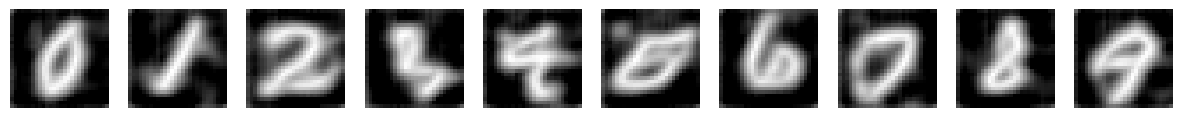

In [40]:
fig, axis = plt.subplots(1, 10, figsize=(15, 2))  
for i in range(10):
    axis[i].imshow(image[i].cpu().squeeze(), cmap='gray')  
    axis[i].axis('off')  
plt.show()